# Six-Stock Demo Walkthrough (QF206)

This notebook walks through the QF206 pipeline on the fixed six-stock demo subset:

- `AAPL`, `MSFT`, `NVDA`, `JPM`, `XOM`, `UNH`

Goals:
- Load the precomputed monthly panel dataset.
- Restrict to the six demo names.
- Inspect factor features and labels (forward 1M returns, top-quintile flag).
- Plot cumulative forward returns and simple factor relationships for teaching/interpretability.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure project src/ is on the path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from config import get_default_config  # type: ignore

cfg = get_default_config()
print("Project root:", cfg.paths.project_root)
print("Monthly panel path:", cfg.paths.data_processed / "monthly_panel.parquet")

Project root: C:\Users\chris\Downloads\fxtrades\qf206_quant
Monthly panel path: C:\Users\chris\Downloads\fxtrades\qf206_quant\data\processed\monthly_panel.parquet


In [2]:
# Load the full monthly panel and restrict to the six demo names
panel_path = cfg.paths.data_processed / "monthly_panel.parquet"
panel = pd.read_parquet(panel_path)
panel["month_end"] = pd.to_datetime(panel["month_end"])

print("Panel shape:", panel.shape)
print("Columns (truncated):", list(panel.columns)[:20], "...")

DEMO_TICKERS = cfg.demo_tickers
panel_demo = panel[panel["ticker"].isin(DEMO_TICKERS)].copy()

panel_demo.sort_values(["ticker", "month_end"], inplace=True)
panel_demo.head()

Panel shape: (54324, 20)
Columns (truncated): ['ticker', 'month_end', 'price', 'ret_1m', 'mom_12_1', 'mom_6_1', 'rev_1m', 'beta_12m', 'vol_3m', 'vol_12m', 'down_vol_12m', 'dollar_vol_1m', 'turnover_proxy', 'amihud', 'overreaction_score', 'disposition_high', 'disposition_low', 'attention_proxy', 'forward_1m_return', 'top_quintile_flag'] ...


,ticker,month_end,price,ret_1m,mom_12_1,mom_6_1,rev_1m,beta_12m,vol_3m,vol_12m,down_vol_12m,dollar_vol_1m,turnover_proxy,amihud,overreaction_score,disposition_high,disposition_low,attention_proxy,forward_1m_return,top_quintile_flag
108,AAPL,2017-01-31,27.943256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.103737e+09,1.126244e+08,1.185178e-12,0.269906,0.747437,0.747437,1.877671,0.133778,True
109,AAPL,2017-02-28,31.681458,0.133778,NaN,NaN,-0.133778,NaN,NaN,NaN,NaN,3.780536e+09,1.246756e+08,1.906380e-12,0.046237,-0.195290,-0.000000,-0.038975,0.048689,True
110,AAPL,2017-03-31,33.224010,0.048689,NaN,NaN,-0.048689,NaN,NaN,NaN,NaN,3.095978e+09,9.504815e+07,1.621811e-12,-0.278912,-0.284951,-0.000000,-0.323751,-0.000070,False
111,AAPL,2017-04-30,33.221687,-0.000070,NaN,NaN,0.000070,NaN,0.156412,NaN,NaN,2.608949e+09,7.889011e+07,1.643814e-12,-0.024037,-0.104650,-0.000000,-0.234418,0.067808,True
112,AAPL,2017-05-31,35.474377,0.067808,NaN,NaN,-0.067808,NaN,0.140695,NaN,NaN,4.166751e+09,1.181674e+08,1.926310e-12,0.004420,-0.011028,-0.000000,0.033187,-0.057214,False


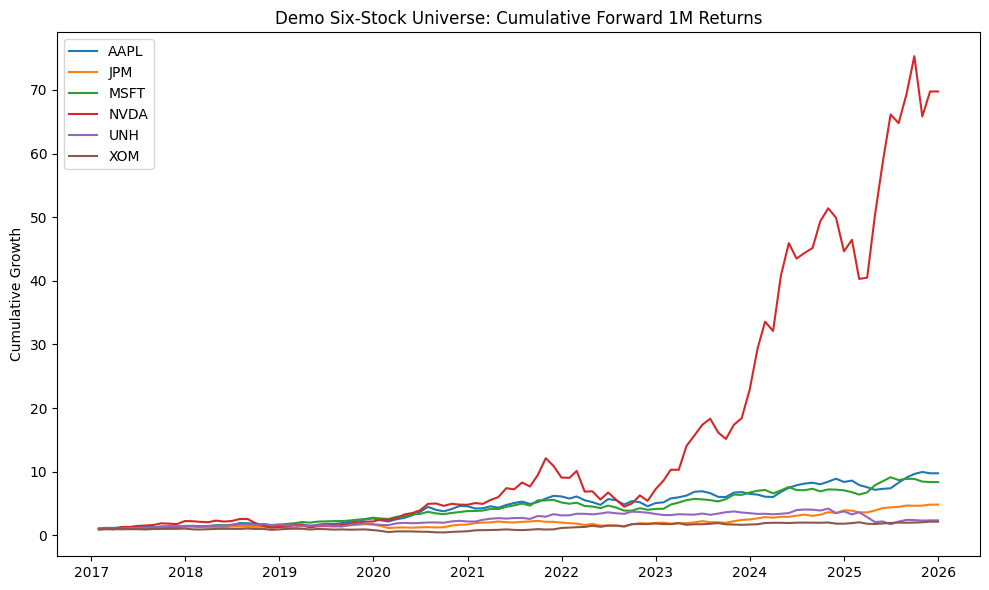

In [3]:
# Plot cumulative forward 1M returns for the six names

fig, ax = plt.subplots(figsize=(10, 6))
for ticker, grp in panel_demo.groupby("ticker"):
    eq = (1.0 + grp.set_index("month_end")["forward_1m_return"].fillna(0.0)).cumprod()
    ax.plot(eq.index, eq.values, label=ticker)

ax.set_title("Demo Six-Stock Universe: Cumulative Forward 1M Returns")
ax.set_ylabel("Cumulative Growth")
ax.legend()
fig.tight_layout()
plt.show()

In [5]:
# Inspect factor features vs. next-month returns for a single name (e.g., AAPL)

single = panel_demo[panel_demo["ticker"] == "AAPL"].copy()

feature_cols = [
    "mom_12_1",
    "mom_6_1",
    "rev_1m",
    "beta_12m",
    "vol_3m",
    "vol_12m",
    "down_vol_12m",
    "dollar_vol_1m",
    "amihud",
    "overreaction_score",
    "disposition_high",
    "disposition_low",
    "attention_proxy",
]

corrs = single[feature_cols + ["forward_1m_return"]].corr()["forward_1m_return"].sort_values(ascending=False)

corrs

forward_1m_return     1.000000
overreaction_score    0.252827
down_vol_12m          0.220906
vol_12m               0.183294
disposition_high      0.176672
vol_3m                0.141781
disposition_low       0.133886
amihud                0.087527
beta_12m              0.081129
attention_proxy       0.017009
rev_1m               -0.094734
mom_12_1             -0.143541
dollar_vol_1m        -0.165729
mom_6_1              -0.202286
Name: forward_1m_return, dtype: float64

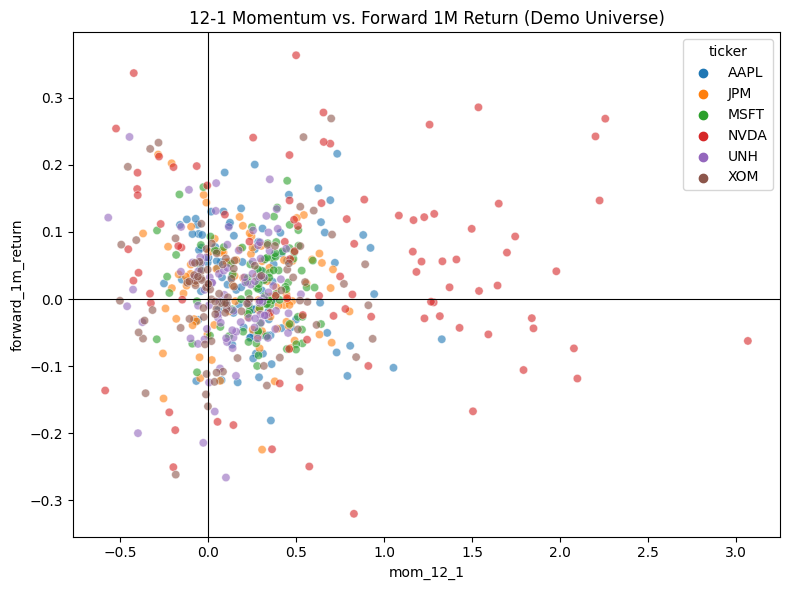

In [6]:
# Simple scatter example: momentum vs. next-month return for the demo universe

fig, ax = plt.subplots(figsize=(8, 6))
subset = panel_demo.dropna(subset=["mom_12_1", "forward_1m_return"]).copy()

sns.scatterplot(
    data=subset,
    x="mom_12_1",
    y="forward_1m_return",
    hue="ticker",
    alpha=0.6,
    ax=ax,
)
ax.set_title("12-1 Momentum vs. Forward 1M Return (Demo Universe)")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axvline(0.0, color="black", linewidth=0.8)
fig.tight_layout()
plt.show()